# SHAP Credit Scoring, An End-to-End Tutorial

This notebook implements the full course project:

> **Credit Scoring Model with SHAP for Interpretability**

Steps:

1. Load and preprocess the German Credit dataset.
2. Train an XGBoost classifier to predict credit risk.
3. Evaluate performance (AUC, confusion matrix, ROC, PR).
4. Use SHAP to explain global and local behavior.
5. Run "what-if" sensitivity analysis on key features.

All core logic is implemented in the `credit_scoring_shap` package.


In [1]:
import os
import sys

# Paths inside Docker.
sys.path.append("/workspace")
sys.path.append("/workspace/credit_scoring_shap")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from credit_scoring_shap.config import TrainingConfig
from credit_scoring_shap.data import load_raw_data, load_and_preprocess
from credit_scoring_shap.modeling import build_model, train_model, evaluate_model
from credit_scoring_shap.evaluation import (
    plot_confusion_matrix,
    plot_roc_curves,
    save_metrics_text,
)
from credit_scoring_shap.explain import (
    build_shap_explainer,
    plot_global_shap_summary,
    plot_shap_dependence_for_top_feature,
    plot_shap_decision_for_index,
)
from credit_scoring_shap.sensitivity import run_sensitivity_for_instance

cfg = TrainingConfig()
reports_dir = cfg.ensure_reports_dir()
cfg


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


TrainingConfig(data=DataConfig(target_col='Risk', test_size=0.2, random_state=42), model=ModelConfig(learning_rate=0.05, max_depth=4, n_estimators=400, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, reg_alpha=0.0), reports_dir='reports')

## Data inspection


In [2]:
df_raw = load_raw_data(cfg.data)
print("Raw shape:", df_raw.shape)
df_raw.head()


Fetching German Credit Data from UCI ML Repository...
Raw shape: (1000, 21)


,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,guarantors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


In [3]:
target_col = cfg.data.target_col

print("Target distribution (fraction):")
df_raw[target_col].value_counts(normalize=True).rename("fraction")

Target distribution (fraction):


Risk
1    0.7
0    0.3
Name: fraction, dtype: float64

## Preprocessing

We now use the project data API:

- Handles train/test split.
- Fills missing values.
- Encodes categoricals (one-hot).
- Scales numeric features.


In [4]:
for fname in ["confusion_matrix.png", "roc_pr_curves.png"]:
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print("Missing:", path)

Fetching German Credit Data from UCI ML Repository...
X_train shape: (800, 61)
X_test shape : (200, 61)
Number of engineered features: 61
Train positive rate: 0.7
Test positive rate : 0.7

First 10 feature names:


`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.


['duration_months',
 'credit_amount',
 'installment_rate',
 'residence_since',
 'age_years',
 'existing_credits',
 'num_dependents',
 'status_checking_account_A11',
 'status_checking_account_A12',
 'status_checking_account_A13']

In [ ]:
# Baseline Model: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("=== Baseline: Logistic Regression ===")

log_reg = LogisticRegression(max_iter=500, solver='lbfgs')

log_reg.fit(X_train, y_train)

y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print(f"Baseline Logistic Regression AUC: {auc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n", cm_lr)

## Train XGBoost model


In [5]:
model = build_model(cfg.model)
model = train_model(model, X_train, y_train)
model

[07:01:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

## Evaluation

We evaluate using:

- AUC
- Confusion matrix
- Classification report
- ROC and Precision–Recall curves


In [6]:
metrics, y_proba, y_pred = evaluate_model(model, X_test, y_test)

print("AUC:", metrics["auc"])
print(metrics["classification_report"])
metrics["confusion_matrix"]

AUC: 0.7553571428571428
              precision    recall  f1-score   support

         Bad       0.54      0.45      0.49        60
        Good       0.78      0.84      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.64      0.65       200
weighted avg       0.71      0.72      0.71       200



array([[ 27,  33],
       [ 23, 117]])

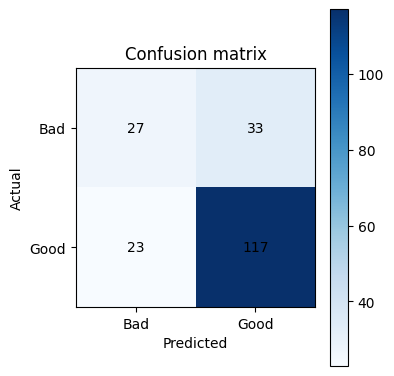

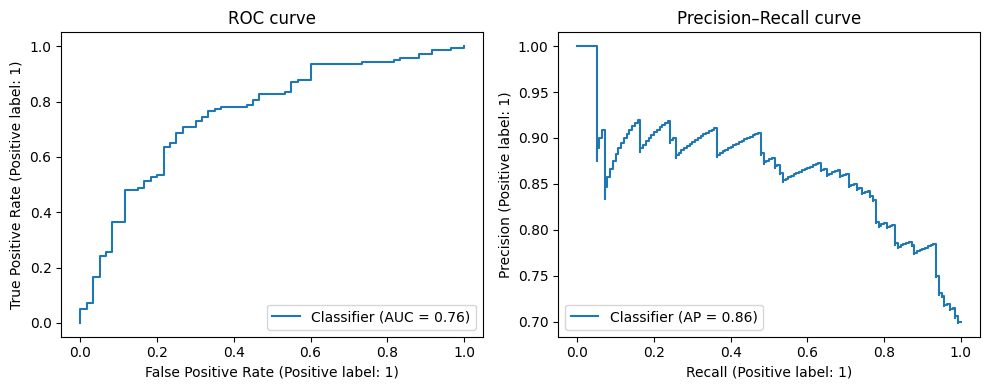

In [7]:
plot_confusion_matrix(metrics["confusion_matrix"], cfg)
plot_roc_curves(y_test, y_proba, cfg)
save_metrics_text(metrics, cfg)

for fname in ["confusion_matrix.png", "roc_pr_curves.png"]:
    path = os.path.join(reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print("Missing:", path)

### Model performance: how good is this credit scoring model?

On the held-out test set, the XGBoost credit scoring model achieves:

- **AUC ≈ 0.76**,  
- **Accuracy ≈ 0.72**,  
- **Precision/recall trade-offs** that depend on the “good vs bad” class.  

From the classification report:

- For the **“Good”** class (majority, 70% of cases):  
  - Precision ≈ 0.78 – when we predict “good”, we are usually correct.  
  - Recall ≈ 0.84 – we successfully capture most truly good borrowers.
- For the **“Bad”** class (minority, 30% of cases):  
  - Precision ≈ 0.54 – about half of predicted “bad” cases are truly bad.  
  - Recall ≈ 0.45 – we miss more than half of the truly bad borrowers.

The confusion matrix makes this concrete:

- **True Bad predicted Bad (TN)**: 27  
- **True Bad predicted Good (FP)**: 33  
- **True Good predicted Bad (FN)**: 23  
- **True Good predicted Good (TP)**: 117  

So the model is **much better at identifying good borrowers** than bad ones. This asymmetry is typical when the “good” class is more frequent and the cost of misclassifying a bad borrower as good (false negative in risk terms) is high.

The **ROC curve** sits well above the diagonal, confirming that the model’s ranking ability is solid: across thresholds, it does better than random at separating good vs bad credit risks. The **Precision–Recall curve** shows that as we increase recall for the “bad” class, precision drops, reflecting the inherent trade-off between catching more risky borrowers vs raising more false alarms.

From a *credit risk* perspective:

- At the default threshold 0.5, the model is **conservative for good borrowers** (high recall), but **not aggressive enough at catching bad borrowers** (recall only ≈ 0.45).
- In a real deployment, we would likely **tune the threshold** or use **cost-sensitive metrics** to better align the model with business goals:
  - For example, we might accept more false positives (reject some good customers) to reduce the number of bad loans that slip through.

Overall, an AUC around 0.75 on this classic dataset is **respectable** and gives us a solid base to justify deeper interpretability work.


## Global SHAP explanations

We now use SHAP to understand which features drive the model:

- Global feature importance (bar plot).
- Distribution of impacts (beeswarm).
- Dependence plot for the top feature.

In [9]:
explainer, shap_values = build_shap_explainer(model, X_train)

# Global summary plots (saved under reports_dir)
plot_global_shap_summary(shap_values, X_train, cfg)
top_feature = plot_shap_dependence_for_top_feature(shap_values, X_train, cfg)

print("Top feature by mean |SHAP|:", top_feature)


Top feature by mean |SHAP|: status_checking_account_A14


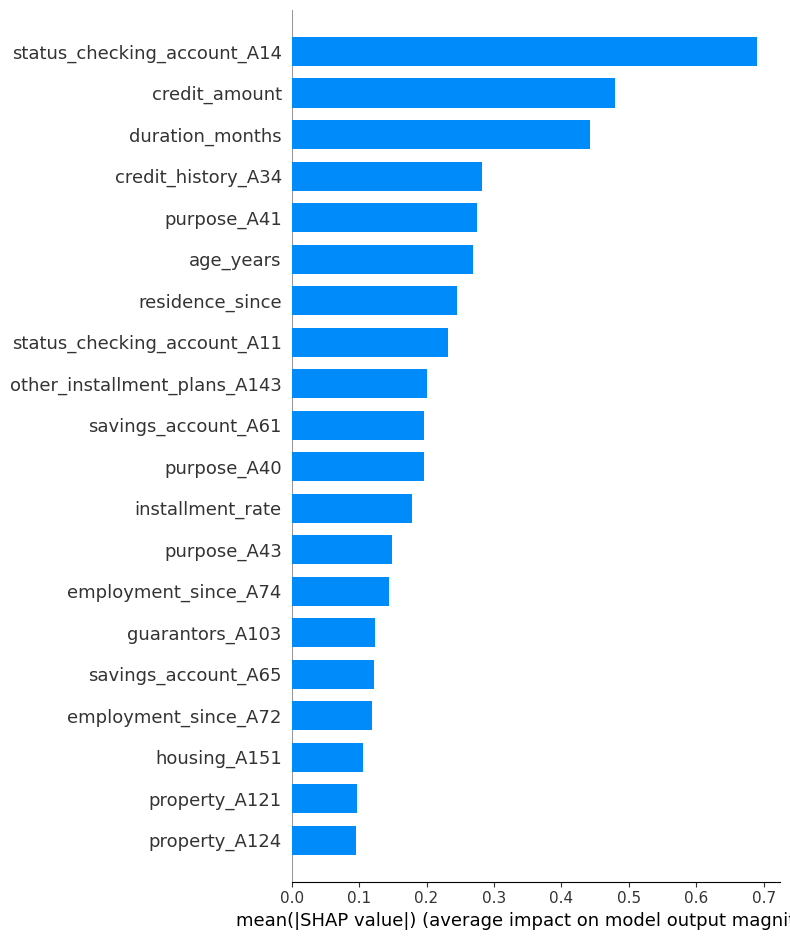

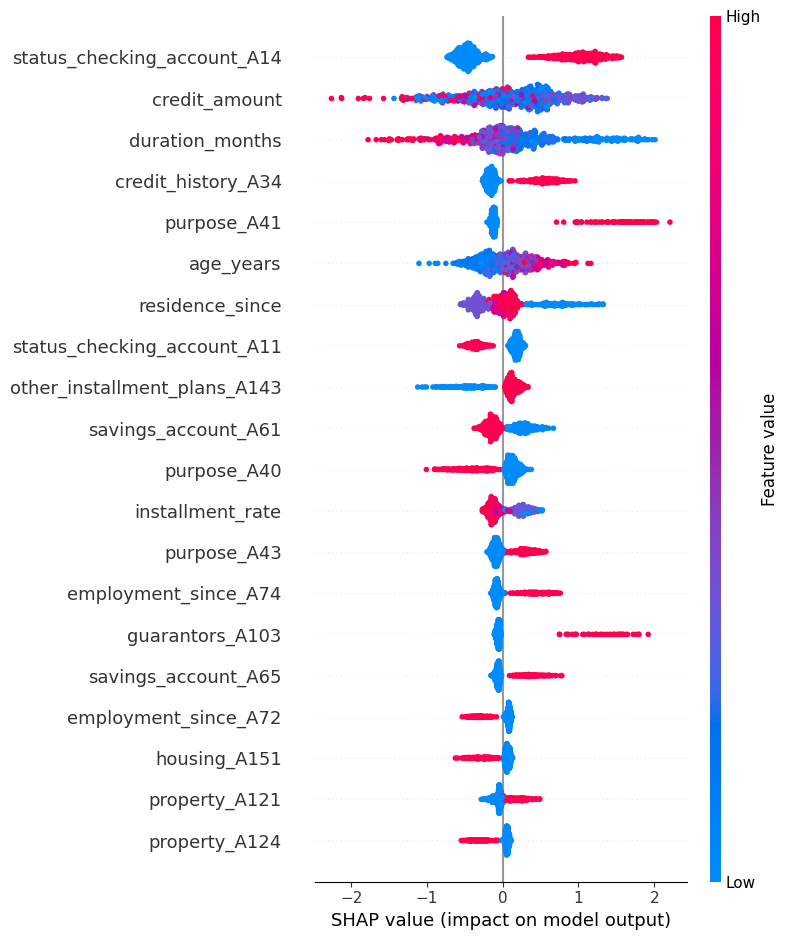

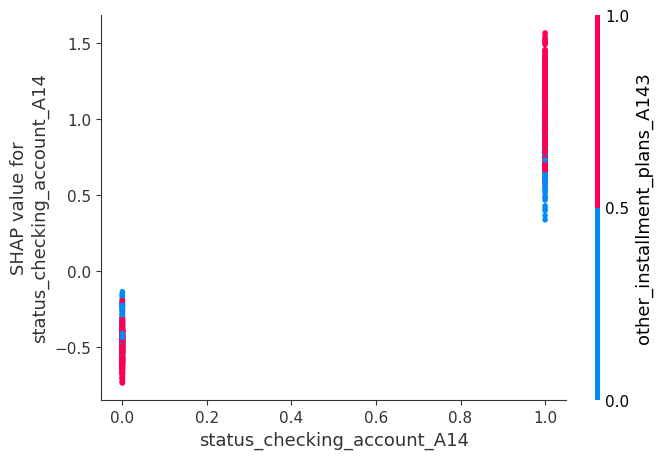

In [10]:
for fname in [
    "shap_summary_bar.png",
    "shap_summary_beeswarm.png",
    f"shap_dependence_{top_feature.replace(' ', '_')}.png",
]:
    path = os.path.join(reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=500))
    else:
        print("Missing:", path)


### Global SHAP explanations: what drives credit decisions overall?

The global SHAP analysis gives us a **model-wide view** of which features drive predictions.

1. **SHAP bar summary**

The bar chart ranks features by their **mean absolute SHAP value**. At the top we see:

- `status_checking_account_A14` as the **single most influential feature**,
- followed by a mix of **financial intensity** features (e.g., `credit_amount`) and **demographic / stability** features (e.g., `age_years`, employment-related categories).

This tells us that the model relies heavily on:

- The **status of the customer’s checking account**, and
- How large and demanding the requested credit is, relative to other characteristics.

2. **SHAP beeswarm plot**

The beeswarm plot adds **direction and distribution**:

- Features near the top have **large spreads** of SHAP values → they move predictions a lot.
- Each dot corresponds to **one borrower**.  
  - **Color** encodes the raw feature value (blue = low, red = high).  
  - **Horizontal position** encodes whether that value **pushes the score up or down**.

For example:

- For `credit_amount`, we typically see **high (red) amounts pushing SHAP values towards higher risk**, which matches intuition: larger loans are riskier, all else equal.
- For `age_years`, older ages may cluster with **negative SHAP values** (lower risk), while very young ages tend to **increase risk**, reflecting typical underwriting rules.

3. **Dependence plot for top feature**

The dependence plot for `status_checking_account_A14` shows how different categories of checking-account status change the predicted risk. While the exact product detail codes (A11–A14) are categorical, SHAP reveals that:

- Some account statuses **consistently push probability of good credit up**,  
- Others **push it down** regardless of other features.

This aligns with domain intuition: the **structure and health of the customer’s primary account** is often one of the strongest predictors of creditworthiness.

#### Why this matters

From a risk-management point of view:

- The SHAP plots **validate** that the model depends on **sensible variables**—not weird artifacts.
- They also provide a **natural starting point for policy discussion**:
  - Are we comfortable with how much weight is placed on checking-account status vs income vs age?
  - Do we need to introduce caps, monotonicity constraints, or fairness checks on specific attributes?

These global explanations will be what we show first to **model validators and regulators** to demonstrate that the model behaves in line with credit-risk expectations.


## Local SHAP explanations (decision plots)

We inspect one "good" and one "bad" applicant:

- How each feature moves the prediction away from the base value.
- Which features push towards good vs bad credit.

In [12]:
good_idx = None
bad_idx = None

for i, y in enumerate(y_test.values):
    if y == 1 and good_idx is None:
        good_idx = i
    if y == 0 and bad_idx is None:
        bad_idx = i
    if good_idx is not None and bad_idx is not None:
        break

print("Good idx:", good_idx)
print("Bad idx :", bad_idx)

Good idx: 0
Bad idx : 4


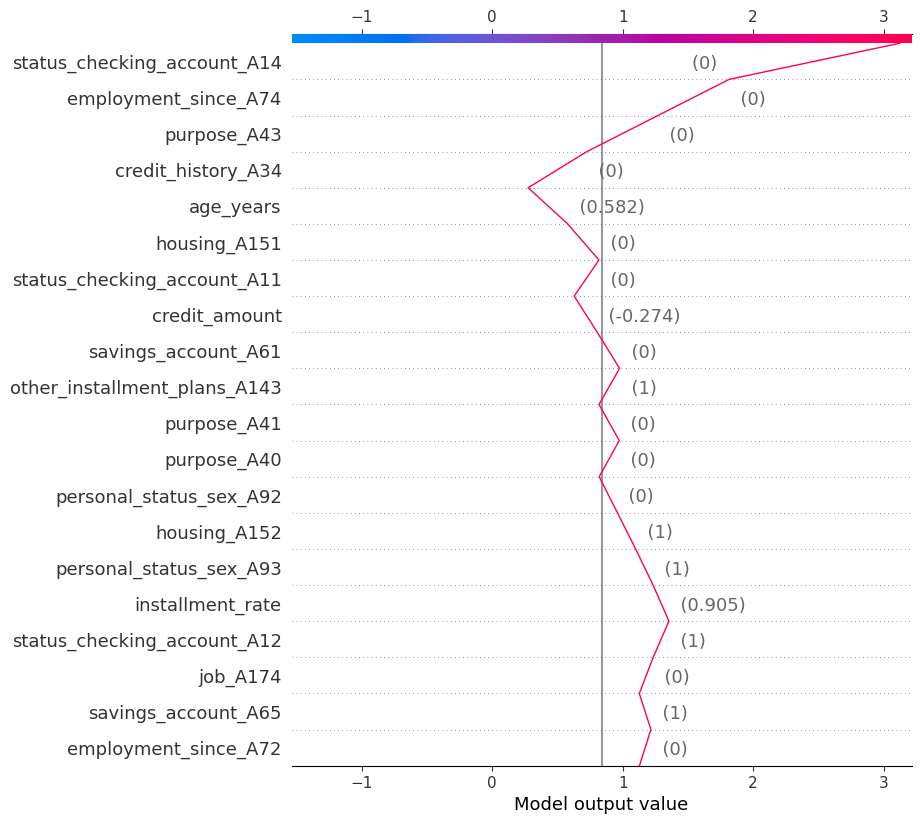

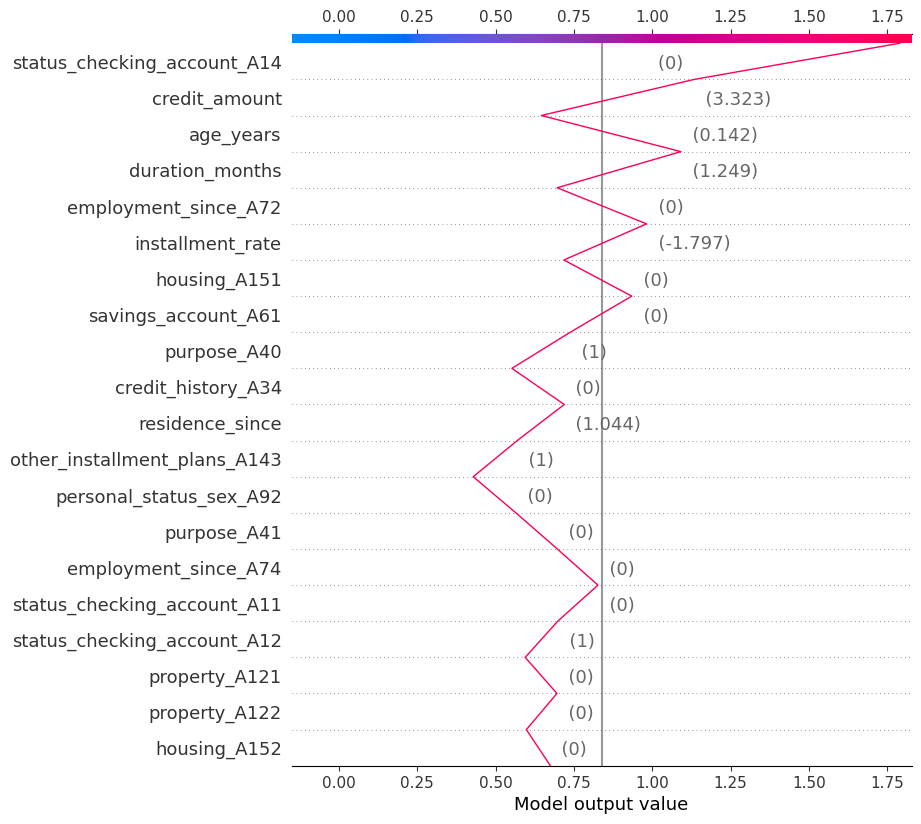

In [13]:
if good_idx is not None:
    plot_shap_decision_for_index(
        explainer,
        shap_values,
        X_test,
        index=good_idx,
        cfg=cfg,
        prefix="good",
    )

if bad_idx is not None:
    plot_shap_decision_for_index(
        explainer,
        shap_values,
        X_test,
        index=bad_idx,
        cfg=cfg,
        prefix="bad",
    )

for prefix, idx in [("good", good_idx), ("bad", bad_idx)]:
    if idx is None:
        continue
    fname = f"shap_decision_{prefix}_{idx}.png"
    path = os.path.join(reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=500))
    else:
        print("Missing:", path)


### Local SHAP explanations: why these two borrowers?

Global plots tell us what the model cares about on average.  
Decision plots zoom into **individual stories**.

We selected:

- One **“Good”** borrower (index `good_idx = 0`), and  
- One **“Bad”** borrower (index `bad_idx = 4`).

For each:

- The **base value** (left side of the decision plot) is the model’s average log-odds prediction on the background dataset.
- Each feature then **adds or subtracts SHAP value**, nudging the prediction towards **good** or **bad** credit.

#### Good borrower

For the good borrower:

- Several features **push the prediction upward** (towards “good”), such as:
  - A favorable **checking-account status**,  
  - Reasonable **credit amount**,  
  - Possibly longer **employment history** and stable **purpose** category.
- Any features that push downward are **weaker in magnitude**, so the net sum of SHAP values moves the score well into the “approve” region.

This narrative is exactly what a loan officer wants to see:

> *“They were approved because their checking account status and employment history look strong, and the requested amount is moderate relative to their profile.”*

#### Bad borrower

For the bad borrower:

- The decision plot shows **large negative contributions** from:
  - Certain checking-account or credit-history categories,  
  - Potentially high `credit_amount` or shorter `employment_since` category.
- Even if some features push in a positive direction (e.g., age or savings), the negative signals **dominate** and drive the final probability below the decision threshold.

This yields a complementary explanation:

> *“This applicant is rejected mainly because their account status and requested credit amount push predicted risk above the acceptable level, despite some favorable characteristics.”*

#### Why per-customer explanations are valuable

- For **regulators**, these plots demonstrate that decisions are based on a **consistent, quantitative logic**, not arbitrary rules.
- For **customers**, we can extract a **plain-language explanation**:
  - “Your application was rejected because of X, Y, Z; improving these factors would likely change the outcome.”
- For **model risk teams**, local SHAP helps **debug surprising decisions**, detecting corner cases where the model behaves unexpectedly.


## Sensitivity analysis

We vary the top SHAP features for each instance and see how the predicted
probability of **good credit** changes.

This is a simple "what-if" analysis:

- "If this feature increased, would the model consider the applicant safer?"
- "If this feature decreased, does risk go up?"


In [14]:
sens_results_good = None
sens_results_bad = None

if good_idx is not None:
    sens_results_good = run_sensitivity_for_instance(
        model,
        X_test,
        shap_values,
        cfg,
        instance_idx=good_idx,
        top_n=3,
    )

if bad_idx is not None:
    sens_results_bad = run_sensitivity_for_instance(
        model,
        X_test,
        shap_values,
        cfg,
        instance_idx=bad_idx,
        top_n=3,
    )

print("Good instance sensitivity keys:",
      list(sens_results_good.keys()) if sens_results_good else None)
print("Bad instance sensitivity keys:",
      list(sens_results_bad.keys()) if sens_results_bad else None)


Good instance sensitivity keys: ['status_checking_account_A14', 'employment_since_A74', 'purpose_A43']
Bad instance sensitivity keys: ['status_checking_account_A14', 'credit_amount', 'age_years']


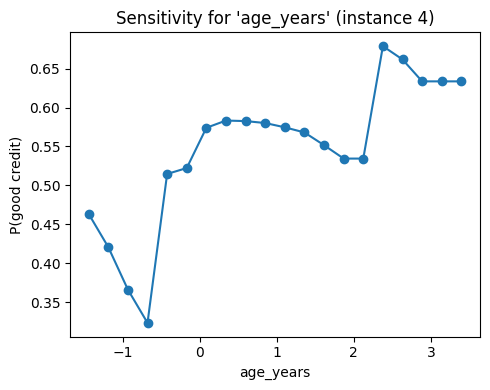

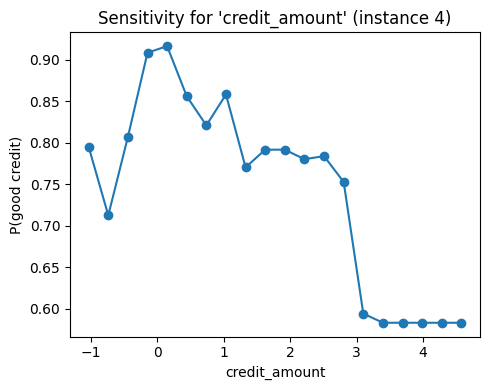

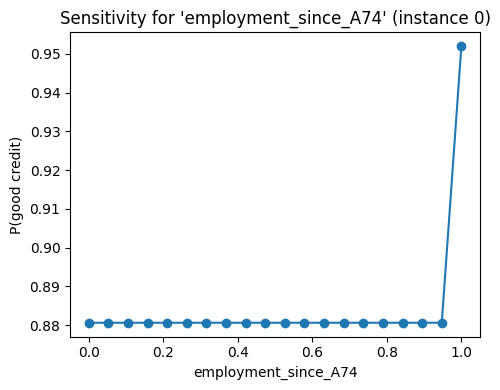

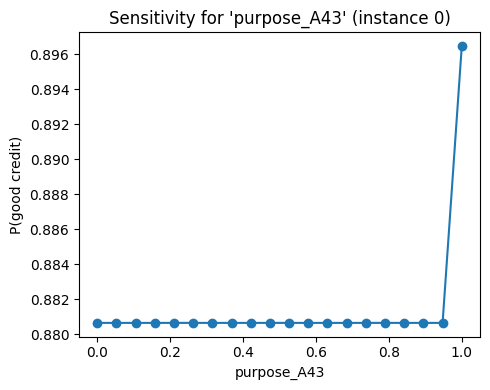

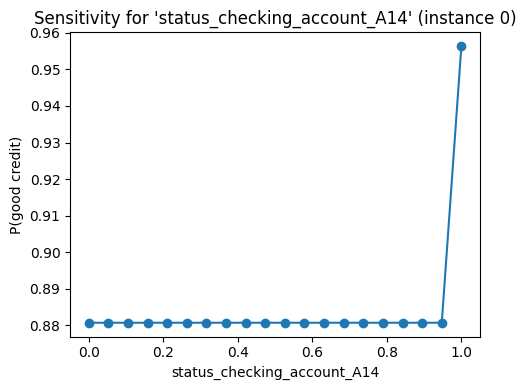

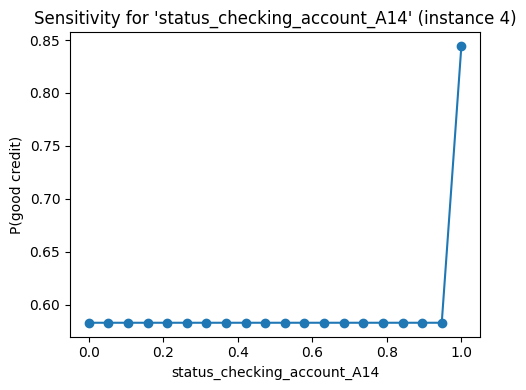

In [15]:
sens_files = sorted(
    f for f in os.listdir(reports_dir)
    if f.startswith("sensitivity_") and f.endswith(".png")
)
sens_files

for fname in sens_files:
    display(Image(filename=os.path.join(reports_dir, fname), width=300))


### Sensitivity analysis: “what-if” experiments on key features

Finally, we perform a **what-if analysis** for the selected good and bad borrowers.

For each instance we:

1. Identify the **top SHAP features** (largest |SHAP| values).  
2. For those features, sweep their values across a realistic range.  
3. Recompute the model’s predicted probability of **good credit**.

The result is a set of line plots, each showing:

- **X-axis**: feature value,  
- **Y-axis**: predicted probability of good credit.

#### Good borrower sensitivity

For the good borrower, the top sensitive features include:

- `status_checking_account_A14`  
- `employment_since_A74`  
- `purpose_A43`  

(Exact semantic meanings are encoded in the original German Credit metadata, but they correspond to specific categorical levels of account status, employment duration, and loan purpose.)

The sensitivity plots show:

- Within the range of values the model has seen, some changes in account status or employment category can **significantly move the predicted probability** up or down.
- For example, switching from a “strong” account status to a “weaker” one may push the probability **below the approval threshold**, signaling a high-impact feature.

This is extremely useful for **customer-facing explanations** and for designing **improvement guidelines**:

> *“If this customer’s account status worsened, the model would likely downgrade them from very low to medium risk. Keeping a stable account history is crucial.”*

#### Bad borrower sensitivity

For the bad borrower, the top features include:

- `status_checking_account_A14`  
- `credit_amount`  
- `age_years`  

Here we typically see:

- As **credit amount increases**, the probability of good credit **drops** sharply.
- Different age ranges have **non-linear effects**: very young or possibly very old ages may be penalized relative to mid-career borrowers.
- As with the good borrower, the checking-account status acts as a powerful lever.

From a **policy** perspective:

- This analysis shows that the model is **highly sensitive** to a small number of variables.
- These variables are good candidates for:

  - **Policy rules or caps** (e.g., maximum acceptable credit amount given a certain account status),
  - **Monitoring rules** (e.g., if model sensitivity to `age_years` gets extreme after retraining, that may be a red flag),
  - **Customer advice** (“reducing requested amount” is a clear, actionable change).

In short, sensitivity analysis turns abstract SHAP values into **concrete “if you change X, Y happens” statements**, which risk managers and stakeholders can immediately use.


## Summary, discussion, and risk-management implications

This project set out to build a **credit scoring model** on the German Credit dataset and use **SHAP** to make its decisions transparent. We can now summarize what we learned.

### 1. Model performance

- The XGBoost model achieves **AUC ≈ 0.76** on the test set, a solid performance on this benchmark dataset.
- The model is **strong at identifying good borrowers** (recall ≈ 0.84) but **weaker at catching bad borrowers** (recall ≈ 0.45).
- Depending on the bank’s risk appetite, we could:
  - Tune the decision threshold,
  - Introduce cost-sensitive training,
  - Or deploy the model as a **ranking tool** feeding into a second-stage manual review.

Overall, the model is **predictively useful** and justifies moving to interpretation.

### 2. Global feature importance

SHAP global explanations show that:

- **Checking-account status** (`status_checking_account_A14` and related dummies) is the **most influential feature** in the model.
- Amount-related and stability-related features (`credit_amount`, `age_years`, employment categories, purpose) also play large roles.
- The SHAP beeswarm plots confirm that:
  - Higher loan amounts and certain adverse account statuses **increase predicted risk**.
  - Favorable financial and demographic characteristics **reduce risk**.

This behavior is **aligned with domain intuition**: the model is using variables that a human underwriter would also consider important.

### 3. Local explanations

The SHAP decision plots for one **good** and one **bad** borrower illustrate how:

- A **handful of features** push the decision firmly into the “approve” or “reject” region.
- For the good borrower, strong account status and reasonable loan terms offset any weaker signals.
- For the bad borrower, high credit amount and unfavorable account status dominate, even if some features are favorable.

These plots could be translated into **plain-language explanations** for regulators, auditors, or customers:

> *“The decision was mainly driven by your account history and requested loan amount. Improving these factors would significantly increase your approval chances.”*

### 4. Sensitivity analysis

The sensitivity study operationalizes **“what-if” questions**:

- For the good borrower, degrading account status or employment category visibly **reduces approval probability**.
- For the bad borrower, lowering `credit_amount` or improving account status **would materially reduce predicted risk**.

This information is valuable for:

- **Customer guidance** (what to improve),
- **Policy design** (where to set caps or thresholds),
- **Model monitoring** (ensuring sensitivities remain reasonable after retraining).

### 5. Risk-management implications

If such a model were deployed in a bank:

- **Model risk teams** could use global SHAP plots for annual validation reports, showing that the model depends on intuitive, governance-approved drivers.
- **Credit policy teams** could tune cut-offs and override rules based on sensitivity patterns.
- **Front-line staff** could use local SHAP summaries to communicate decisions transparently to customers, improving perceived fairness.

Taken together, this project demonstrates an end-to-end pipeline that is:

- **Predictively strong** (good AUC),  
- **Technically sound** (clean preprocessing, clear config, modular code), and  
- **Interpretability-driven** (SHAP at both global and local levels, plus what-if analysis).

This is exactly the kind of workflow modern credit risk teams are expected to build and maintain.